In [1]:
#!pip install gradio

In [1]:
from segment_anything  import SamAutomaticMaskGenerator, sam_model_registry, SamPredictor

In [2]:
from diffusers import StableDiffusionInpaintPipeline

In [3]:
model_type= 'vit_h'
checkpoint= "C:/Users/DIBYOJIT/Downloads/sam_vit_h_4b8939.pth"

In [4]:
sam= sam_model_registry[model_type](checkpoint=checkpoint).to("cpu")

In [21]:
img_bgr= cv2.imread("C:/Users/DIBYOJIT/Downloads/doggy.jpeg")
img_rgb= cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_bgr= cv2.resize(img_bgr, (512, 512), interpolation=None)
img_rgb= cv2.resize(img_rgb, (512, 512), interpolation=None)

print(img_bgr.shape, img_rgb.shape)

(512, 512, 3) (512, 512, 3)


In [22]:
mask_generator= SamAutomaticMaskGenerator(sam)
result= mask_generator.generate(img_rgb)
print(result[0].keys())
print(len(result))

dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
90


In [23]:
bbox= []
points=[]
segmentation= []
area= []

for mask in result:
    bbox.append(mask['bbox'])
    points.append(mask['point_coords'])
    segmentation.append(mask['segmentation'])
    area.append(mask['area'])
    print(mask['bbox'])

[189, 79, 88, 264]
[0, 0, 189, 101]
[418, 0, 93, 334]
[76, 383, 15, 48]
[0, 0, 445, 380]
[278, 321, 24, 13]
[50, 227, 150, 55]
[262, 236, 185, 51]
[52, 333, 459, 29]
[1, 382, 45, 51]
[3, 321, 43, 15]
[133, 283, 64, 47]
[48, 162, 152, 56]
[250, 382, 43, 29]
[52, 333, 459, 43]
[255, 174, 189, 53]
[255, 174, 189, 108]
[293, 44, 41, 48]
[50, 165, 394, 62]
[409, 289, 37, 44]
[390, 327, 7, 7]
[74, 327, 17, 6]
[50, 173, 150, 109]
[436, 356, 29, 21]
[156, 172, 43, 46]
[51, 227, 396, 60]
[52, 237, 459, 140]
[4, 333, 49, 48]
[278, 286, 92, 48]
[317, 428, 27, 55]
[93, 283, 39, 50]
[133, 283, 150, 50]
[166, 0, 24, 18]
[258, 488, 10, 13]
[0, 129, 12, 15]
[93, 219, 39, 114]
[143, 320, 53, 14]
[156, 490, 18, 17]
[388, 355, 77, 40]
[104, 363, 70, 43]
[449, 478, 27, 16]
[59, 499, 14, 7]
[138, 364, 36, 20]
[353, 500, 23, 11]
[143, 320, 159, 14]
[45, 498, 28, 8]
[383, 356, 82, 94]
[383, 396, 27, 54]
[459, 432, 15, 22]
[395, 481, 14, 16]
[140, 286, 231, 48]
[303, 495, 16, 16]
[361, 424, 17, 45]
[115, 248,

In [24]:
segmentation= [segment['segmentation'] for segment in sorted(result, key= lambda x: x['area'], reverse=True)]
bbox= [bbox['bbox'] for bbox in sorted(result, key= lambda x: x['area'], reverse=True)]
points= [point['point_coords'] for point in sorted(result, key= lambda x: x['area'], reverse=True)]

print(bbox)
print(points)
print(segmentation)

[[0, 0, 445, 380], [418, 0, 93, 334], [50, 173, 397, 114], [51, 227, 396, 60], [189, 79, 88, 264], [0, 0, 189, 101], [52, 237, 459, 140], [52, 333, 459, 43], [52, 333, 459, 29], [255, 174, 189, 53], [255, 174, 189, 108], [50, 165, 394, 62], [262, 236, 185, 51], [50, 173, 150, 109], [50, 227, 150, 55], [48, 162, 152, 56], [140, 286, 231, 48], [278, 286, 92, 48], [383, 356, 82, 94], [133, 283, 150, 50], [133, 283, 64, 47], [388, 355, 77, 40], [104, 363, 70, 43], [1, 382, 45, 51], [4, 333, 49, 48], [93, 219, 39, 114], [93, 283, 39, 50], [409, 289, 37, 44], [156, 172, 43, 46], [293, 44, 41, 48], [383, 396, 27, 54], [257, 264, 21, 76], [262, 223, 106, 14], [143, 320, 159, 14], [250, 382, 43, 29], [75, 328, 16, 103], [76, 383, 15, 48], [138, 364, 36, 20], [143, 320, 53, 14], [436, 356, 29, 21], [453, 459, 38, 21], [317, 428, 27, 55], [3, 321, 43, 15], [361, 424, 17, 45], [332, 499, 44, 12], [449, 478, 27, 16], [361, 423, 16, 35], [480, 312, 31, 33], [278, 321, 24, 13], [166, 0, 24, 18], [377

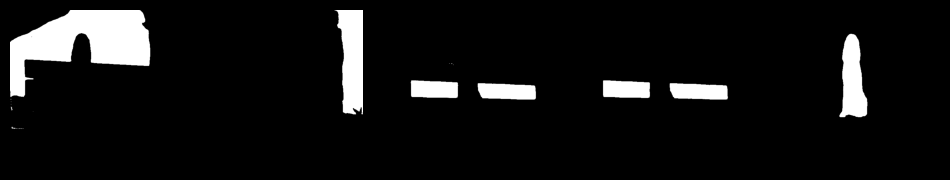

In [25]:
import supervision as sv

sv.plot_images_grid(
segmentation[0:5],
grid_size=(1,5)
)

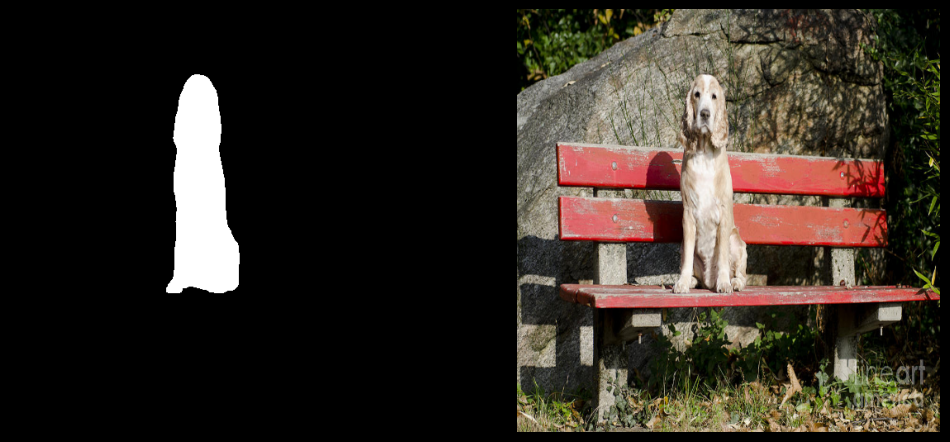

In [26]:
sv.plot_images_grid(
images= [segmentation[4], img_bgr],
    grid_size=(1,2)
)

In [27]:
prompt= "An bulldog sitting on a bench"
mask_image= Image.fromarray(segmentation[4])

In [48]:
out= pipe(prompt=prompt, image=img_rgb, mask_image=mask_image).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

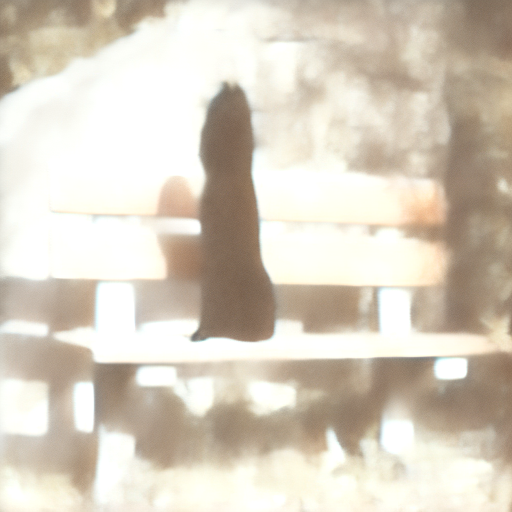

In [50]:
out

In [21]:
pipeline= StableDiffusionInpaintPipeline.from_pretrained(
"runwayml/stable-diffusion-inpainting",
)

safety_checker\model.safetensors not found


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\DIBYOJIT\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\51388a731f57604945fddd703ecb5c50e8e7b49d\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\DIBYOJIT\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\51388a731f57604945fddd703ecb5c50e8e7b49d\vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch C:\Users\DIBYOJIT\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\51388a731f57604945fddd703ecb5c50e8e7b49d\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\DIBYOJIT\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\51388a731f57604945fddd703ecb5c50e8e7b49d\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [22]:
pipeline.to("cpu")

StableDiffusionInpaintPipeline {
  "_class_name": "StableDiffusionInpaintPipeline",
  "_diffusers_version": "0.30.0",
  "_name_or_path": "runwayml/stable-diffusion-inpainting",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "DDIMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [33]:
prompt= "An cat sitting on a bench "

In [41]:
def download_image(url):
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert("RGB")


img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

init_image = download_image(img_url).resize((512, 512))
mask_image = download_image(mask_url).resize((512, 512))

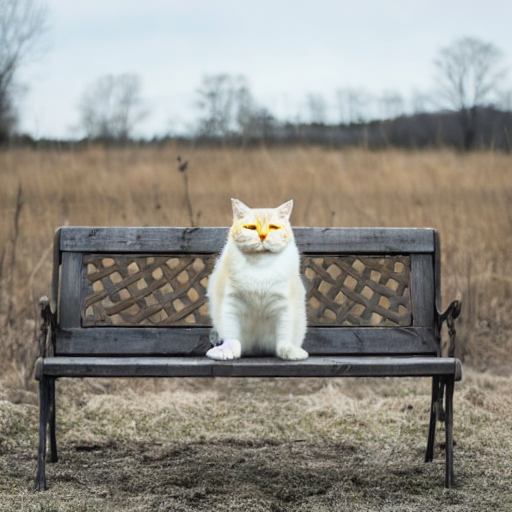

In [39]:
image

In [57]:
plt.imsave('seg mask.png', segmentation[4])

In [80]:
image_url= "https://i.postimg.cc/RFqg0dsk/doggy.jpg"
mask_url= "https://i.postimg.cc/wMRHDhvP/seg-mask.png"

In [81]:
init_image= download_image(image_url).resize((512, 512))
mask_image= download_image(mask_url).resize((512, 512))

In [82]:
prompt= "A white panda sitting n a bench"

In [83]:
diff_image = pipeline(prompt=prompt, image=init_image, mask_image=mask_image).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

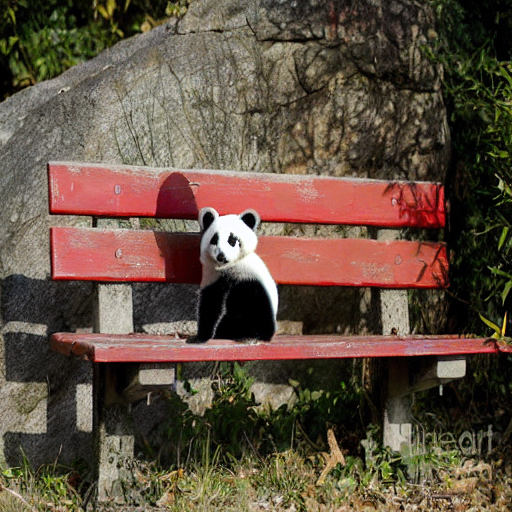

In [84]:
diff_image

In [46]:
image_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint.png"
mask_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint_mask.png"

In [48]:
init_image= download_image(image_url).resize((512, 512))
mask_image= download_image(mask_url).resize((512, 512))

In [49]:
prompt= "concept art digital painting of an elven castle, inspired by lord of the rings, highly detailed, 8k"

In [50]:
des_image = pipeline(prompt=prompt, image=init_image, mbask_image=mask_image).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

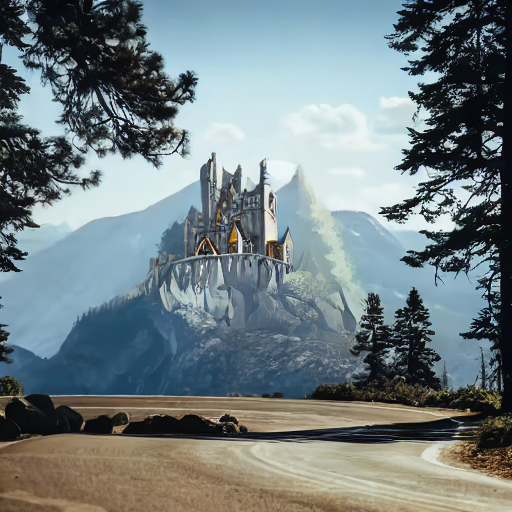

In [51]:
des_image

In [99]:
img_bgr= cv2.imread("C:/Users/DIBYOJIT/Downloads/koala.jpeg")
img_rgb= cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_bgr= cv2.resize(img_bgr, (512, 512), interpolation=None)
img_rgb= cv2.resize(img_rgb, (512, 512), interpolation=None)

print(img_bgr.shape, img_rgb.shape)

(512, 512, 3) (512, 512, 3)


In [100]:
mask_generator= SamAutomaticMaskGenerator(sam)
result= mask_generator.generate(img_rgb)
print(result[0].keys())
print(len(result))

dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
71


In [101]:
bbox= []
points=[]
segmentation= []
area= []

for mask in result:
    bbox.append(mask['bbox'])
    points.append(mask['point_coords'])
    segmentation.append(mask['segmentation'])
    area.append(mask['area'])
    print(mask['bbox'])

[214, 46, 204, 430]
[411, 0, 100, 461]
[411, 0, 100, 298]
[0, 92, 25, 63]
[150, 40, 27, 51]
[291, 127, 22, 46]
[9, 0, 17, 38]
[55, 1, 16, 70]
[180, 0, 14, 23]
[96, 354, 11, 24]
[0, 468, 58, 43]
[97, 308, 10, 19]
[180, 243, 39, 14]
[83, 287, 10, 15]
[197, 456, 61, 28]
[41, 158, 26, 56]
[101, 113, 23, 21]
[192, 263, 14, 9]
[96, 484, 22, 27]
[453, 46, 13, 39]
[60, 163, 31, 111]
[271, 132, 12, 13]
[60, 398, 30, 47]
[241, 0, 20, 39]
[62, 319, 19, 33]
[57, 81, 16, 56]
[390, 340, 121, 48]
[27, 0, 15, 31]
[349, 0, 31, 51]
[484, 131, 8, 13]
[43, 164, 48, 110]
[339, 0, 70, 511]
[465, 160, 11, 29]
[366, 0, 13, 28]
[387, 358, 14, 42]
[236, 400, 16, 33]
[95, 377, 22, 37]
[0, 0, 78, 45]
[451, 316, 18, 30]
[150, 0, 27, 46]
[245, 281, 149, 191]
[220, 0, 41, 39]
[0, 395, 64, 116]
[0, 450, 62, 61]
[97, 188, 17, 45]
[0, 327, 72, 84]
[0, 132, 136, 31]
[130, 161, 10, 159]
[0, 254, 71, 156]
[229, 490, 14, 21]
[0, 393, 127, 118]
[366, 255, 31, 141]
[299, 483, 24, 28]
[42, 496, 15, 15]
[270, 0, 13, 34]
[0, 24

In [102]:
segmentation= [segment['segmentation'] for segment in sorted(result, key= lambda x: x['area'], reverse=True)]
bbox= [bbox['bbox'] for bbox in sorted(result, key= lambda x: x['area'], reverse=True)]
points= [point['point_coords'] for point in sorted(result, key= lambda x: x['area'], reverse=True)]

print(bbox)
print(points)
print(segmentation)

[[214, 46, 204, 430], [411, 0, 100, 461], [411, 0, 100, 298], [245, 281, 149, 191], [339, 0, 70, 511], [0, 393, 127, 118], [0, 395, 64, 116], [0, 450, 62, 61], [366, 255, 31, 141], [366, 0, 40, 396], [60, 163, 31, 111], [43, 164, 48, 110], [0, 468, 58, 43], [339, 444, 41, 67], [90, 141, 26, 92], [220, 0, 41, 39], [130, 161, 10, 159], [197, 456, 61, 28], [412, 350, 12, 161], [199, 318, 49, 79], [390, 340, 121, 48], [0, 132, 136, 31], [150, 40, 27, 51], [0, 327, 72, 84], [291, 127, 22, 46], [41, 158, 26, 56], [0, 254, 71, 156], [215, 195, 31, 36], [0, 249, 82, 61], [0, 0, 78, 45], [241, 0, 20, 39], [0, 92, 25, 63], [57, 81, 16, 56], [60, 398, 30, 47], [193, 12, 21, 61], [55, 1, 16, 70], [349, 0, 31, 51], [150, 0, 27, 46], [97, 188, 17, 45], [307, 468, 31, 43], [9, 0, 17, 38], [96, 484, 22, 27], [387, 358, 14, 42], [451, 316, 18, 30], [299, 483, 24, 28], [453, 46, 13, 39], [27, 0, 15, 31], [95, 377, 22, 37], [236, 400, 16, 33], [180, 243, 39, 14], [101, 113, 23, 21], [62, 319, 19, 33], [2

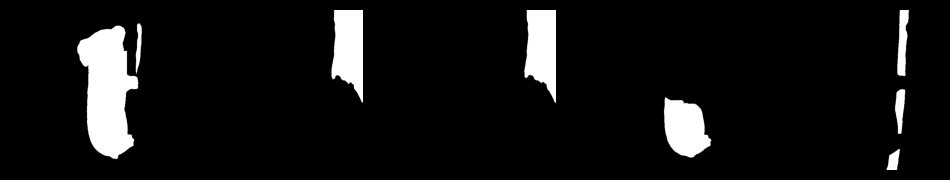

In [103]:
import supervision as sv

sv.plot_images_grid(
segmentation[0:5],
grid_size=(1,5)
)

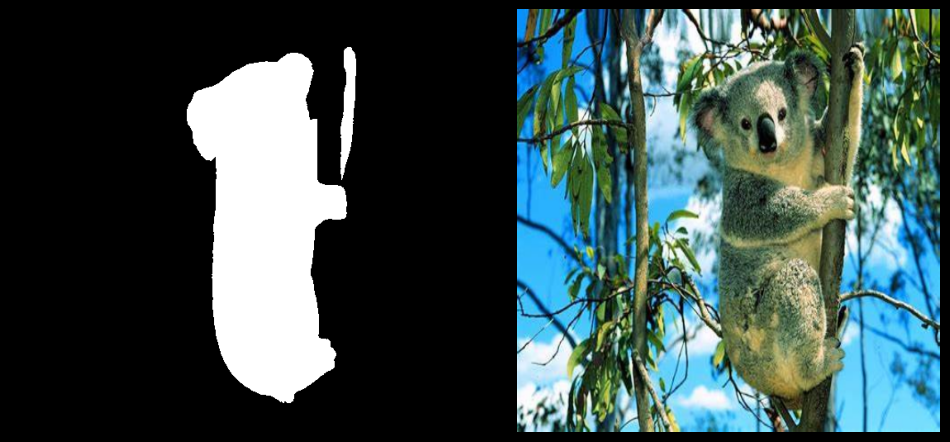

In [104]:
sv.plot_images_grid(
images= [segmentation[0], img_bgr],
    grid_size=(1,2)
)

In [93]:
plt.imsave('koala_mask.jpg', segmentation[0])

In [105]:
image_url="https://i.postimg.cc/t49X1n3q/koala.jpg"
mask_url= "https://i.postimg.cc/SKTNbQzy/koala-mask.jpg"

In [106]:
init_image= download_image(image_url).resize((512, 512))
mask_image= download_image(mask_url).resize((512, 512))

In [107]:
prompt= "A giant green anaconda crawling on the tree branch"

In [108]:
img=  pipeline(prompt=prompt, image=init_image, mask_image=mask_image).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

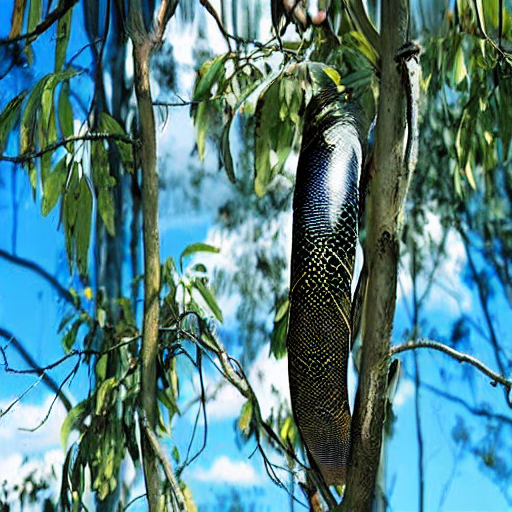

In [109]:
img

In [5]:
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [6]:
img_bgr= cv2.imread("C:/Users/DIBYOJIT/Downloads/zebra.jpeg")
img_rgb= cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_bgr= cv2.resize(img_bgr, (512, 512), interpolation=None)
img_rgb= cv2.resize(img_rgb, (512, 512), interpolation=None)

print(img_bgr.shape, img_rgb.shape)

(512, 512, 3) (512, 512, 3)


In [7]:
mask_generator= SamAutomaticMaskGenerator(sam)
result= mask_generator.generate(img_rgb)
print(result[0].keys())
print(len(result))

dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
21


In [8]:
bbox= []
points=[]
segmentation= []
area= []

for mask in result:
    bbox.append(mask['bbox'])
    points.append(mask['point_coords'])
    segmentation.append(mask['segmentation'])
    area.append(mask['area'])
    print(mask['bbox'])

[0, 0, 511, 511]
[52, 56, 446, 394]
[0, 0, 167, 20]
[51, 163, 28, 49]
[87, 495, 19, 16]
[357, 382, 19, 62]
[398, 83, 102, 98]
[372, 227, 22, 11]
[257, 416, 38, 35]
[364, 97, 19, 11]
[483, 265, 28, 57]
[112, 494, 15, 17]
[216, 56, 4, 60]
[0, 205, 18, 12]
[454, 494, 23, 17]
[188, 318, 31, 88]
[372, 268, 12, 22]
[217, 403, 33, 38]
[358, 405, 18, 39]
[169, 43, 4, 47]
[39, 42, 3, 45]


In [9]:
segmentation= [segment['segmentation'] for segment in sorted(result, key= lambda x: x['area'], reverse=True)]
bbox= [bbox['bbox'] for bbox in sorted(result, key= lambda x: x['area'], reverse=True)]
points= [point['point_coords'] for point in sorted(result, key= lambda x: x['area'], reverse=True)]

print(bbox)
print(points)
print(segmentation)

[[0, 0, 511, 511], [52, 56, 446, 394], [0, 0, 167, 20], [398, 83, 102, 98], [483, 265, 28, 57], [188, 318, 31, 88], [357, 382, 19, 62], [51, 163, 28, 49], [257, 416, 38, 35], [217, 403, 33, 38], [358, 405, 18, 39], [87, 495, 19, 16], [216, 56, 4, 60], [454, 494, 23, 17], [112, 494, 15, 17], [169, 43, 4, 47], [0, 205, 18, 12], [364, 97, 19, 11], [372, 268, 12, 22], [39, 42, 3, 45], [372, 227, 22, 11]]
[[[104.0, 504.0]], [[376.0, 312.0]], [[120.0, 8.0]], [[488.0, 104.0]], [[488.0, 296.0]], [[200.0, 360.0]], [[360.0, 392.0]], [[56.0, 184.0]], [[264.0, 424.0]], [[248.0, 424.0]], [[376.0, 408.0]], [[104.0, 504.0]], [[216.0, 72.0]], [[456.0, 504.0]], [[120.0, 504.0]], [[168.0, 72.0]], [[8.0, 216.0]], [[376.0, 104.0]], [[376.0, 280.0]], [[40.0, 72.0]], [[392.0, 232.0]]]
[array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [False,  True,  True, ...,  True,  Tru

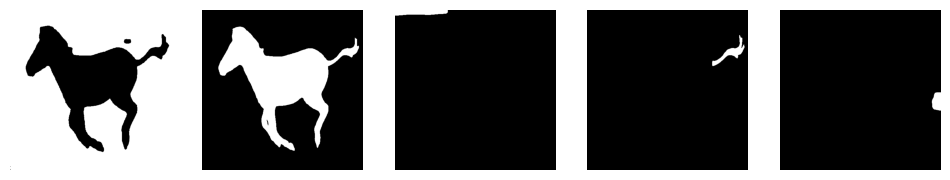

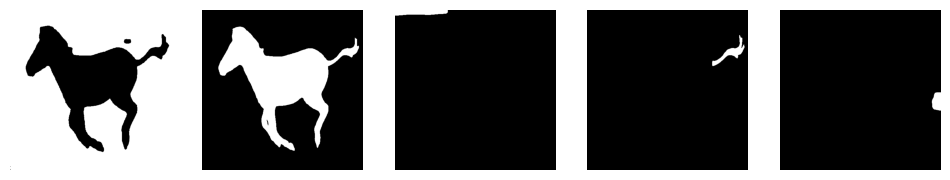

In [11]:
%matplotlib inline 
import supervision as sv

sv.plot_images_grid(
segmentation[0:5],
grid_size=(1,5)
)

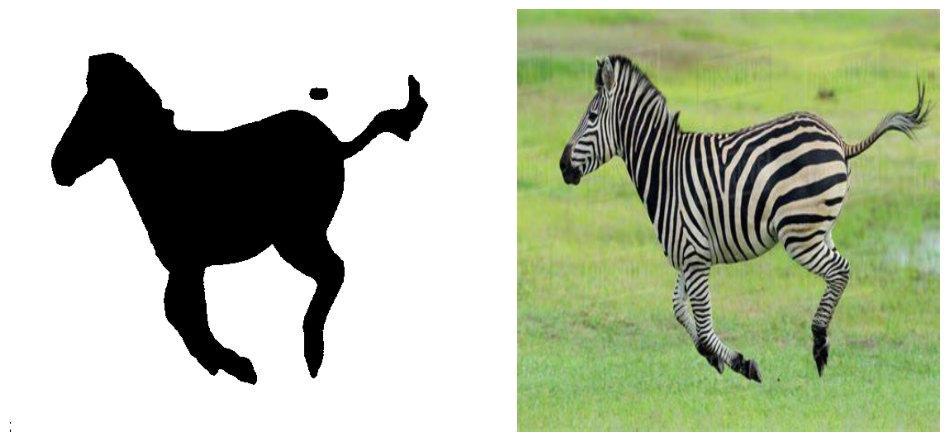

In [12]:
sv.plot_images_grid(
images= [segmentation[0], img_bgr],
    grid_size=(1,2)
)

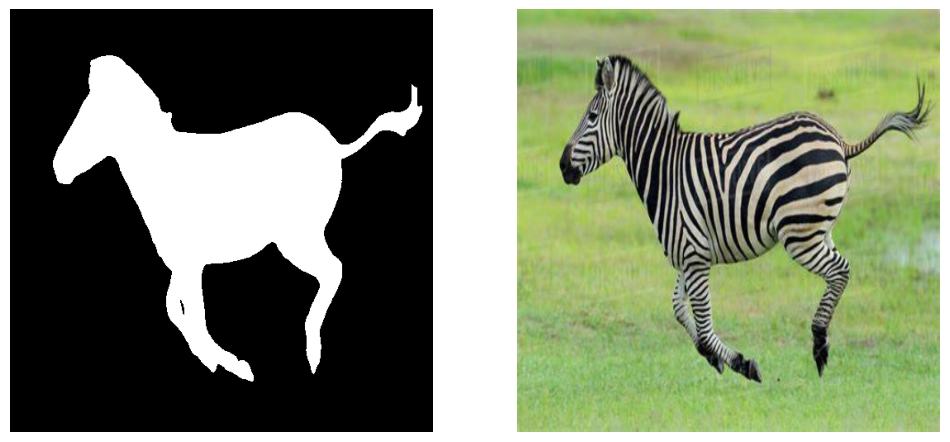

In [13]:
sv.plot_images_grid(
images= [segmentation[1], img_bgr],
    grid_size=(1,2)
)

In [43]:
plt.imsave('zebra_mask.jpg', segmentation[0])

In [14]:
plt.imsave('zebra_mask_2.jpg', segmentation[1])

In [15]:
image_url= "https://i.postimg.cc/4yy23HVM/zebra.jpg"
mask_url = "https://i.postimg.cc/50nk1SYL/zebra-mask-2.jpg"

In [16]:
from io import BytesIO
import requests
from PIL import Image

In [17]:
def download_image(url):
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert("RGB")

In [18]:
init_image= download_image(image_url).resize((512, 512))
mask_image= download_image(mask_url).resize((512, 512))

In [19]:
prompt= "A horse running through the jungle"

In [23]:
horse= pipeline(prompt=prompt, image=init_image, mask_image=mask_image).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

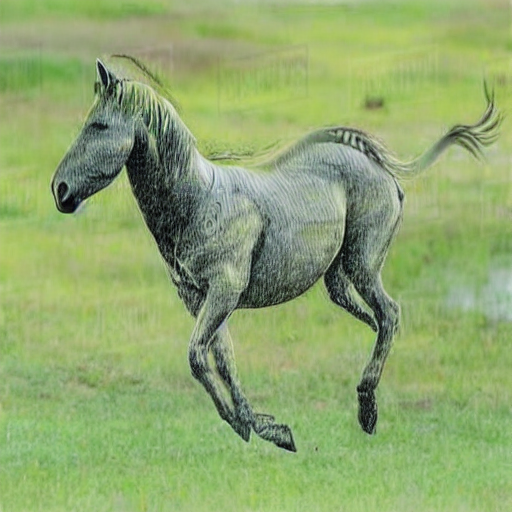

In [24]:
horse

In [27]:
img_bgr= cv2.imread("C:/Users/DIBYOJIT/OneDrive/Documents/Pictures/BlueStacks/img.jpg")
img_rgb= cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_bgr= cv2.resize(img_bgr, (512, 512), interpolation=None)
img_rgb= cv2.resize(img_rgb, (512, 512), interpolation=None)

print(img_bgr.shape, img_rgb.shape)

(512, 512, 3) (512, 512, 3)


In [28]:
mask_generator= SamAutomaticMaskGenerator(sam)
result= mask_generator.generate(img_rgb)
print(result[0].keys())
print(len(result))

dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
86


In [29]:
bbox= []
points=[]
segmentation= []
area= []

for mask in result:
    bbox.append(mask['bbox'])
    points.append(mask['point_coords'])
    segmentation.append(mask['segmentation'])
    area.append(mask['area'])
    print(mask['bbox'])

[19, 65, 353, 446]
[19, 245, 345, 266]
[199, 188, 152, 43]
[34, 353, 37, 31]
[368, 407, 52, 36]
[177, 124, 171, 248]
[0, 332, 40, 52]
[400, 342, 33, 25]
[452, 383, 36, 30]
[0, 248, 21, 19]
[368, 408, 85, 35]
[0, 351, 40, 33]
[400, 433, 74, 40]
[34, 333, 37, 51]
[433, 343, 31, 25]
[387, 361, 45, 29]
[0, 376, 55, 33]
[498, 0, 13, 19]
[418, 383, 36, 32]
[187, 64, 186, 115]
[0, 375, 16, 19]
[3, 278, 34, 21]
[361, 433, 45, 40]
[0, 214, 511, 297]
[0, 0, 511, 232]
[0, 0, 511, 477]
[0, 311, 22, 26]
[343, 409, 39, 34]
[344, 463, 58, 45]
[13, 401, 39, 38]
[400, 433, 44, 40]
[439, 433, 41, 39]
[440, 406, 51, 36]
[354, 0, 148, 19]
[25, 475, 18, 20]
[434, 20, 29, 10]
[419, 362, 46, 28]
[238, 324, 24, 17]
[0, 136, 46, 18]
[235, 2, 32, 10]
[382, 383, 39, 33]
[0, 0, 511, 142]
[0, 404, 23, 35]
[477, 434, 34, 39]
[267, 5, 30, 9]
[453, 384, 58, 31]
[484, 384, 27, 31]
[336, 433, 32, 41]
[236, 2, 61, 12]
[463, 344, 31, 25]
[476, 495, 35, 16]
[461, 23, 32, 10]
[203, 0, 32, 9]
[326, 450, 7, 8]
[493, 344, 18,

In [30]:
segmentation= [segment['segmentation'] for segment in sorted(result, key= lambda x: x['area'], reverse=True)]
bbox= [bbox['bbox'] for bbox in sorted(result, key= lambda x: x['area'], reverse=True)]
points= [point['point_coords'] for point in sorted(result, key= lambda x: x['area'], reverse=True)]

print(bbox)
print(points)
print(segmentation)

[[19, 65, 353, 446], [0, 0, 511, 477], [0, 0, 511, 232], [0, 214, 511, 297], [19, 245, 345, 266], [0, 0, 511, 142], [0, 214, 186, 297], [19, 324, 183, 187], [177, 124, 171, 248], [349, 134, 162, 98], [187, 64, 186, 115], [199, 188, 152, 43], [120, 0, 391, 34], [200, 188, 70, 42], [299, 0, 212, 19], [354, 0, 148, 19], [344, 463, 58, 45], [361, 433, 45, 40], [400, 433, 74, 40], [464, 462, 47, 42], [441, 462, 70, 43], [400, 433, 44, 40], [439, 433, 41, 39], [13, 401, 39, 38], [477, 434, 34, 39], [0, 376, 55, 33], [368, 407, 52, 36], [368, 408, 85, 35], [440, 406, 51, 36], [0, 332, 40, 52], [0, 351, 40, 33], [0, 430, 38, 35], [336, 433, 32, 41], [343, 409, 39, 34], [382, 383, 39, 33], [34, 333, 37, 51], [34, 353, 37, 31], [418, 383, 36, 32], [0, 136, 46, 18], [324, 475, 36, 32], [452, 383, 36, 30], [387, 361, 45, 29], [419, 362, 46, 28], [453, 384, 58, 31], [484, 384, 27, 31], [363, 362, 37, 29], [5, 295, 45, 22], [400, 342, 33, 25], [463, 344, 31, 25], [433, 343, 31, 25], [0, 404, 23, 35]

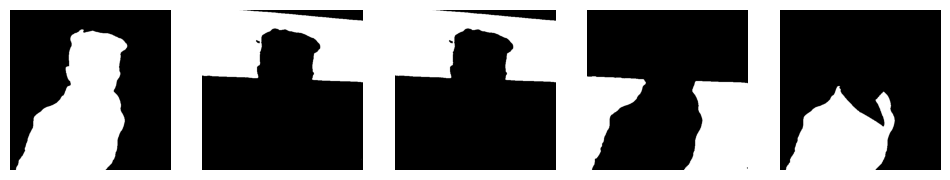

In [31]:
%matplotlib inline 
import supervision as sv

sv.plot_images_grid(
segmentation[0:5],
grid_size=(1,5)
)

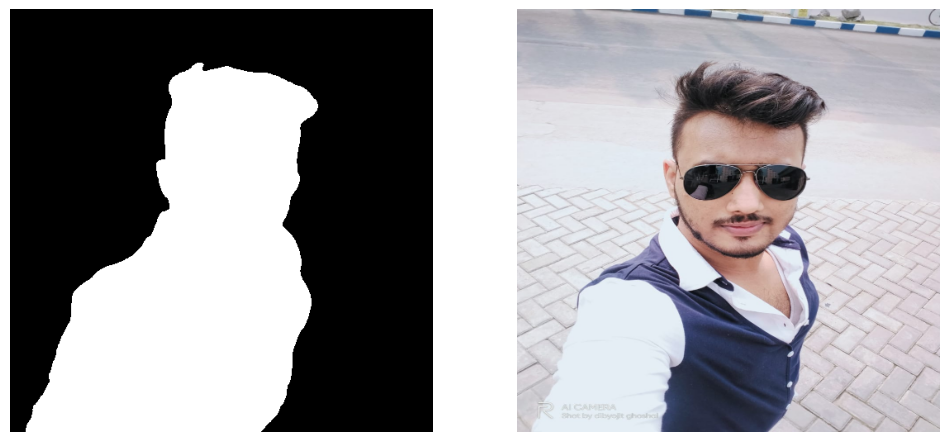

In [33]:
sv.plot_images_grid(
images= [segmentation[0], img_bgr],
    grid_size=(1,2)
)

In [34]:
plt.imsave('human_seg.jpg', segmentation[0])
plt.imsave('human_seg_head.jpg', segmentation[1])
plt.imsave('human_seg_body.jpg', segmentation[4])

In [35]:
image_url= "https://i.postimg.cc/Zqvhfryp/img.jpg"
mask_url= "https://i.postimg.cc/Wp80nKcR/human-seg.jpg"

In [36]:
init_image= download_image(image_url).resize((512, 512))
mask_image= download_image(mask_url).resize((512, 512))

In [37]:
prompt= "Shah Rukh Khan with long hair and black spectacles taking a selfie"

In [38]:
human= pipeline(prompt=prompt, image=init_image, mask_image=mask_image).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

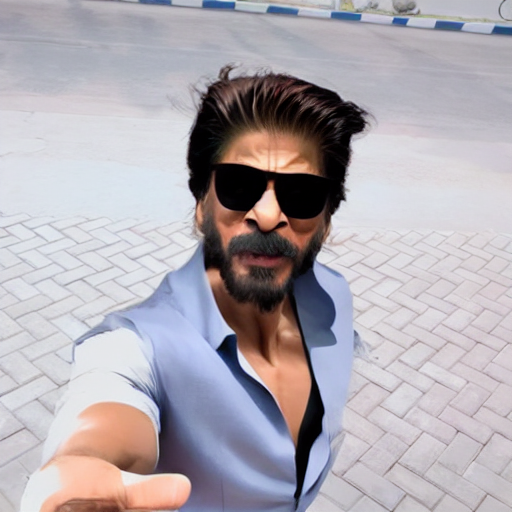

In [39]:
human

In [40]:
prompt= "Hrithik Roshanwith long hair and black spectacles taking a selfie"

In [41]:
hrithik= pipeline(prompt=prompt, image=init_image, mask_image=mask_image).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

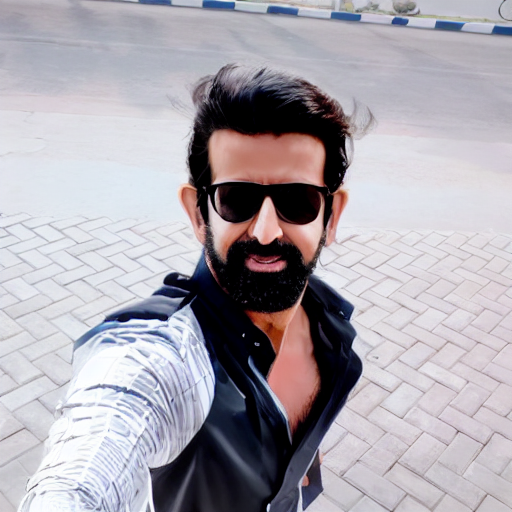

In [42]:
hrithik